In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv('datos/bf_dataset.csv')

In [3]:
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,NaN,NaN,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,NaN,NaN,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,NaN,NaN,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,NaN,NaN,365


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


# 1

## a)

    Tenemos que las variables numéricas son:
    - ``User ID``
    - ``Ocupation``
    - ``Marital_Status``
    - ``Product_Category_1``
    - ``Product_Category_2``
    - ``Product_Category_3``
    - ``Purchase``

    Mientras que las variables categoricas son:
    - ``Product_ID``
    - ``Gender``
    - ``Age``
    - ``City_Category``
    - ``Stay_In_Current_City_Years``

    Pero algo a tener en cuenta es que categorias como ``Product_ID`` parecen arrancar siempre con P al inicio, pero pueden identificarse como numéricas si se elimina la P. (supongo que es de producto)

    ``Age`` es un rango de edades, podría imputarse en categorías numéricas. Siendo 0 aquella menores de 18 años, 1, 2, etc para lo que sigue. 

    Despues varias categorías como ``City_Category`` o ``Ocupation`` estan codificadas, que ahora mismo no sabría que significan. 

Las variables demográficas son:
- ``Gender``
- ``Age``
- ``Ocupation``
- ``Marital_Status``

Las variables geográficas son:
- ``City_Category``
- ``Stay_In_Curret_City_Years``

Las variables de producto son: 
- ``Product_Category_1``
- ``Product_Category_2``
- ``Product_Category_3``

Identificadores
- ``Product_ID`` (De producto)
- ``User_ID`` (De cliente)

Capaz las variables de comportamiento de compra pueden ser:
- ``Stay_In_Curret_City_Years`` (Un recienn mudado compra más)
- ``Marital_Status`` (Cumpleaños, aniversarios, etc)
- ``Purchase`` (Cuanto gastó/o podría gastar)
- ``Age`` (Hay rangos de edad que más compran por poder adquisitivo)
- ``Gender`` 

* 

De igual manera el comportamiento de compra, mientras más lo pieso puede llegar a ser todas las categorias.

In [5]:
attributes = data.columns

## b)

In [6]:
print('Existen',data[attributes[0]].unique().shape[0],'usuarios distintos')

Existen 5891 usuarios distintos


A cada cliente lo podemos identificar por su ID, por lo que podemos ver que existen 5891 clientes distintos.

## c)

No tenemos información temporal, lo único que tenemos es la cantidad de Items que compró y el precio de cada item. Cada fila es un item comprado, pero no sabemos si los compró todos juntos o si los compró en períodos de tiempo diferente.

Como no tenemos una serie temporal no sabemos bien cuando podemos hacer ofertas a la persona. A principio de mes, segunda quincena, fin de mes? Cuando tienen dinero la persona? Cuando es el cumpleaños de su pareja por ejemplo? 

Lo que compró fue por alguna fecha especial y aprovecho las ofertas? o porque venía esperando comprar eso y lo compro en oferta? Siempre compra?

Son muchas preguntas que al no tener ningún dato temporal no lo sabemos. 

El único dato temporal que podemos llegar a tener es el de cuanto tiempo hace que vive donde vive. Capaz hizo muchas compras de mudanza, compro cosas más grandes. O capaz que esa gente gasta igual que los que hace mucho que viven ahí. 

A priori no tenemos ningún indicio temporal en el set de datos. Así que no podemos saber si hay momentos que el cliente compra mas o menos. 

## d)

In [7]:
data.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

Si tenemos datos nulos, solamente en ``Product_Category_2`` y ``Product_Category_3`` . Esto puede ser solamente porque son sub categorías del producto. 

(Poner /  ver los porcentajes de nulos/completos)

Esto a mi parecer no sería ningún impedimento. Supogamos que tenemos que alguien compra un tele. Si es plano, curvo, OLED, LCD etc etc ... capaz no es taaaan importante, como que compro un tele. Capaz. Con la info que tenemos para una prediccion inicial un product category 1 es suficiente. Capas tambien que si es ropa capas si tengamos las demás categorias completas, si son muebles capas menos categorias. No se ... pienso. 

Los productos que no tienen categoria 2 o 3 es porque no tienen asignada una sub-categoria.

## e)

In [8]:
print('Existen',data[attributes[8]].unique().shape[0],'categorias distintas')
print('Existen',data[attributes[1]].unique().shape[0],'productos distintas')


Existen 20 categorias distintas
Existen 3631 productos distintas


Si lo que queremos es *predecir el monto de compra de un cliente para distintos productos**, 

In [9]:
print('Existen',data[attributes[-1]].unique().shape[0],'precios distintas')


Existen 18105 precios distintas


In [10]:
attributes[-1]

'Purchase'

Si. La columna `Purchase` es justamente nuestra columna objetivo para hacer aprendizaje supervisado. 

Y representa lo que pago cada cliente por el producto comprado (sea cual sea y la cantidad que fue)


# 2)

## a)

In [11]:
categorias_numericas = data.select_dtypes(include=[np.number])

In [12]:
categorias_numericas.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


Las variables `User_ID`, `Occupation`, `Marital_Status` y `Product_Category_1/2/3` no son numéricas en sentido estadístico. Son variables categóricas, codificadas numéricamente. El número es una etiqueta categorica, no una magnitud. Aplicarles medidas como la media o los cuantiles no tiene interpretación de negocio.

- `User_ID` por ejemplo es una serie numerica única que representa cada uno de los usuarios de la plataforma. Siendo 5891 de las ~550.000 entradas. Por lo que calcular su media nos daría un numero de un cliente que no existe probablemente. Sería más relevante ver que cliente fue el que más items compró, o el cliente que más dinero gastó.

- `Marital_Status` por otro lado toma solo valores 0 y 1. Lo más seguro es que represente **casado** y **soltero**, pero no sabemos cual es cual. Nuevamente es más útil contar la moda, pero no la media, la cual es 0.41. Podemos ver que hay más 0, pero el 0.41 como tal no aporta nada. Igual que los cuartiles. 

Adicionalmente, `Product_Category_2` (376.430 velores no nulos) y `Product_Categor_3` (166.821 de 550.068) presentan una alta proporción de nulos, lo cual, como vimos en el 1.d, responde a una razón estructural del catálogo y no a datos faltantes por error. 

En general todas las variables tienen el mismo comportamiento, excepto por `Purchase`. Esta es la única variable numérica **real**

Donde tenemos que:
(Todos los valores son unidades monetarias, cuya unidad no es especificada en el dataset)
| Estadístico | Valor       |
|-------------|-------------|
| Media       | 9.263,97    |
| Mediana     | 8.047,00    |
| Mínimo      | 12,00       |
| Máximo      | 23.961,00   |
| Cuantil 25% | 5.823,00    |
| Cuantil 75% | 12.054,00   |

## b)

### Atributo `Purchase`

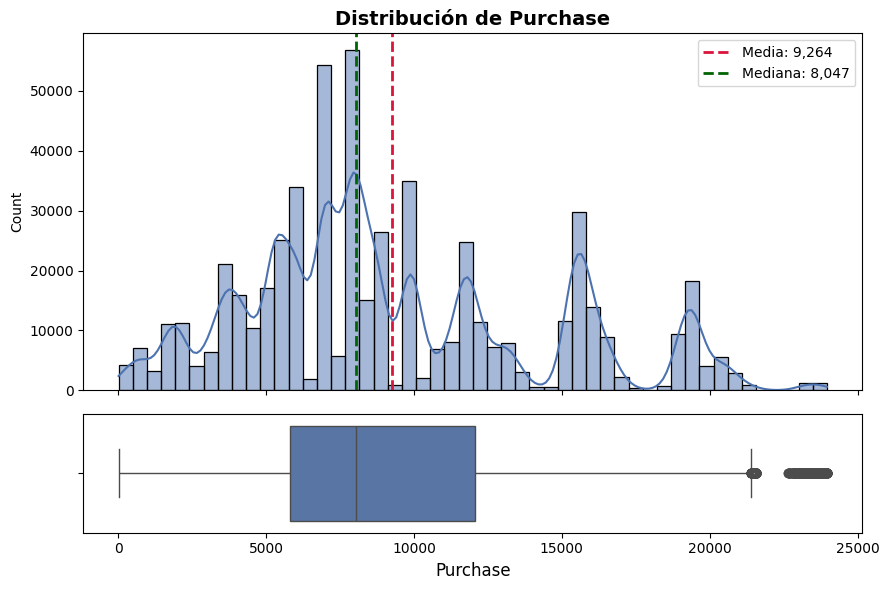

In [46]:
fig, (ax_hist, ax_box) = plt.subplots(
    2, 1,
    figsize=(9, 6),
    sharex=True,                       
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(data['Purchase'], bins=50, kde=True, color="#4C72B0", ax=ax_hist)
ax_hist.set_title("Distribución de Purchase", fontsize=14, fontweight="bold")
ax_hist.set_xlabel("")

media = data['Purchase'].mean()
mediana = data['Purchase'].median()

ax_hist.axvline(media, color="crimson", linestyle="--", linewidth=2,
                 label=f"Media: {media:,.0f}")
ax_hist.axvline(mediana, color="darkgreen", linestyle="--", linewidth=2,
                 label=f"Mediana: {mediana:,.0f}")

ax_hist.legend(fontsize=10)

sns.boxplot(x=data['Purchase'], color="#4C72B0", ax=ax_box)
ax_box.set_xlabel("Purchase", fontsize=12)

plt.tight_layout()
plt.show()

La distribución de `Purchase` es multimodal, con varios picos bien diferenciados en lugar de una única campana. Esto probablemente se deba a que distintas categorías de producto tienen rangos de precio característicos — hipótesis que se puede confirmar coloreando el histograma por `Product_Category_1` (queda para un análisis posterior).

Los valores que el boxplot marca como outliers se ubican en la cola superior de la distribución. Sin embargo, no se trata de errores de carga: son transacciones reales de montos altos, por lo que no corresponde eliminarlos del análisis.

Además, la media ($9.264) es mayor que la mediana ($8.047), lo cual indica un sesgo positivo (hacia la derecha): la cola de compras de mayor monto "estira" el promedio por encima del valor típico de la distribución.

### Atributo `Gender`

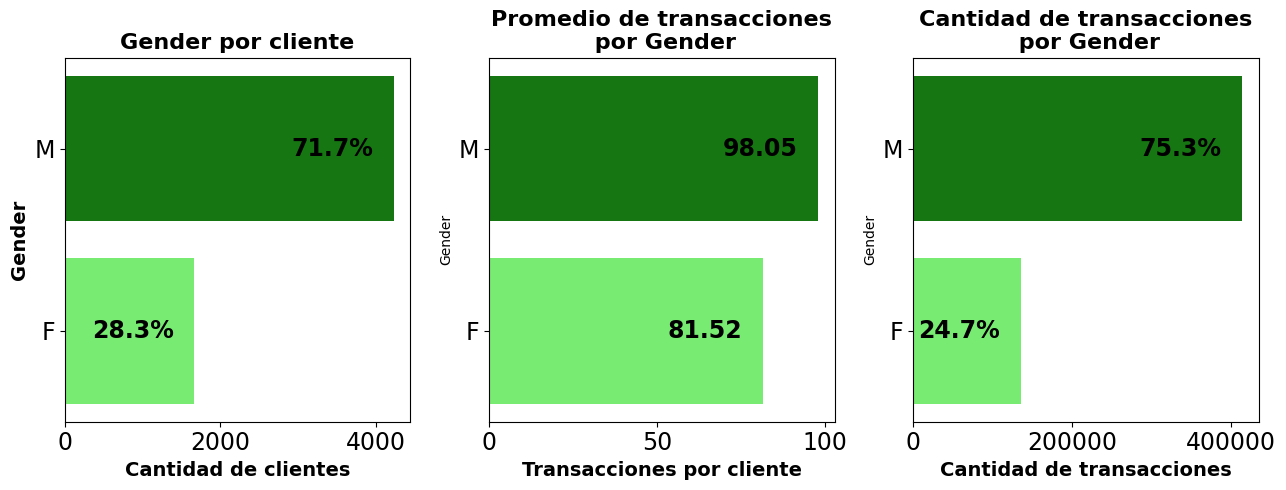

In [47]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

palette_gender = {'M': "#078700", 'F': "#66FF5E"}

# Panel 1: por cliente único
sns.countplot(y='Gender', data=usuarios_unicos,
              order=usuarios_unicos['Gender'].value_counts().index,
              ax=axes[0],
              hue='Gender',
              palette=palette_gender,
              legend=False)
axes[0].set_title('Gender por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje,
        (ancho, p.get_y() + p.get_height() / 2.0),
        ha='right', va='center',
        xytext=(-15, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 2: transacciones promedio por género
tx_por_cliente = (
    data.groupby(['User_ID', 'Gender']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Gender')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Gender', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Gender'],
    ax=axes[1], hue='Gender', palette=palette_gender,
    orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Gender', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}',
        (ancho, p.get_y() + p.get_height() / 2.0),
        ha='right', va='center',
        xytext=(-15, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 3: por transacción
sns.countplot(y='Gender', data=data,
              order=data['Gender'].value_counts().index,
              ax=axes[2], hue='Gender', palette=palette_gender,
              legend=False)
axes[2].set_title('Cantidad de transacciones\n por Gender', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(data)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje,
        (ancho, p.get_y() + p.get_height() / 2.0),
        ha='right', va='center',
        xytext=(-15, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

plt.tight_layout()
plt.show()

Haciendo un análisis del `Gender` de los clientes vemos que hay un mayor número de Hombres (~72%) que de Mujeres (~28%). 

Asimismo, se observa que los hombres realizan, en promedio, un ~20% más de transacciones por cliente que las mujeres (98.05 vs. 81.52), lo cual explica por qué su participación en el total de transacciones (75.3%) es mayor a su participación en la base de clientes (71.7%). 

La diferencia no es grande, pero existe. Más adelante evaluaremos el dinero generado por cada transacción según el género, y si esta diferencia tiene algún impacto.

### Atributo `Age`

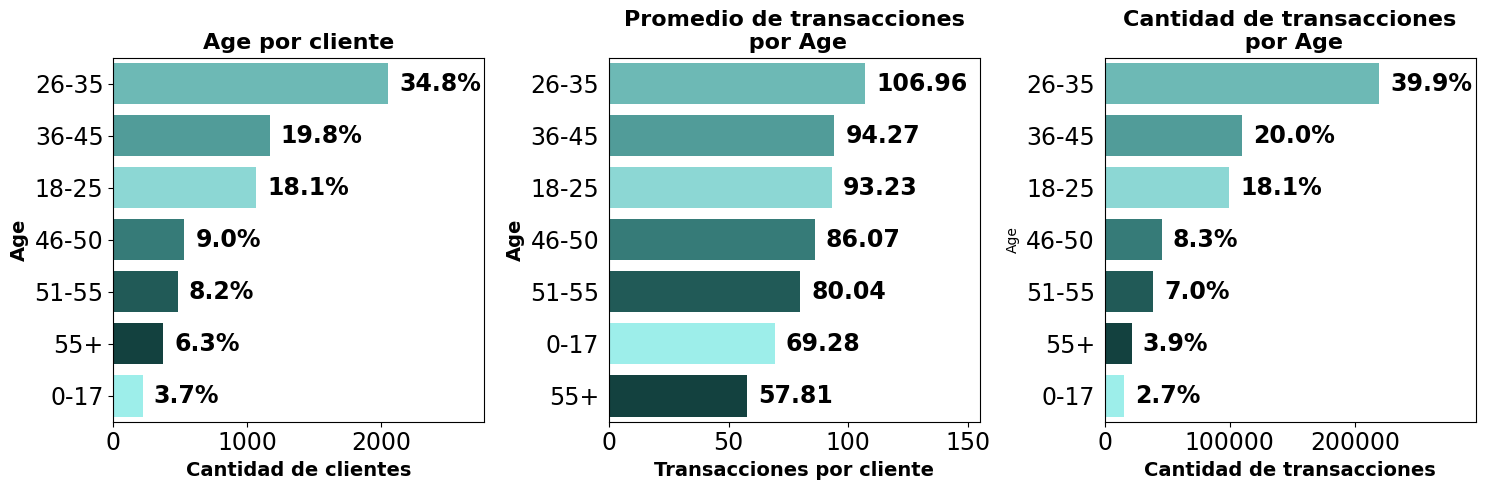

In [48]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_age = {
    '0-17': '#90fbf6',
    '18-25': '#7fe4df',
    '26-35': '#60c6c1',
    '36-45': '#44a9a4',
    '46-50': '#2a8782',
    '51-55': '#176460',
    '55+': '#0b4946'
    }

# Panel 1: por cliente único
sns.countplot(y='Age', data=usuarios_unicos,
              order=usuarios_unicos['Age'].value_counts().index,
              ax=axes[0], hue='Age', palette=palette_age, legend=False)
axes[0].set_title('Age por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[0].set_xlim(0, usuarios_unicos['Age'].value_counts().max() * 1.35)

# Panel 2: transacciones promedio por Age
tx_por_cliente = (
    data.groupby(['User_ID', 'Age']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Age')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Age', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Age'],
    ax=axes[1], hue='Age', palette=palette_age, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Age', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Age', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='y', left=False)
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.45)

# Panel 3: por transacción
sns.countplot(y='Age', data=data,
              order=data['Age'].value_counts().index,
              ax=axes[2], hue='Age', palette=palette_age, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Age', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Age', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='y', left=False)
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(data)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[2].set_xlim(0, data['Age'].value_counts().max() * 1.35)



plt.tight_layout()
plt.show()

Analizando Age vemos que la edad con el mayor porcentaje de clientes es 26 y 35 años, representando ~35% del total, y los menos representados son los de 0-17 años, solo el ~4%. Vemos también que el mayor promedio de transacciones también lo tienen los clientes de 26 a 35 años. El promedio entre los clientes de 36 a 45 es muy similar al de 18 a 25, aunque los primeros tienen 1 compra más (~94 a ~93). Pero, a diferencia de la cantidad de clientes por edad, vemos que aquí los de 55+ (el ~6% de los clientes) son los que menos transacciones hacen (~58), mientras que los de 0 a 17 años realizan en promedio ~69 transacciones. Por último, vemos que el orden de representación entre grupos etarios se mantiene igual al comparar cantidad de clientes y cantidad de transacciones — el ranking de los siete grupos no cambia — aunque las proporciones sí se corren: los grupos con mayor promedio de transacciones (como 26-35) ganan peso relativo en el total de transacciones respecto a su peso en la base de clientes.

### Atributo ``City_Category``

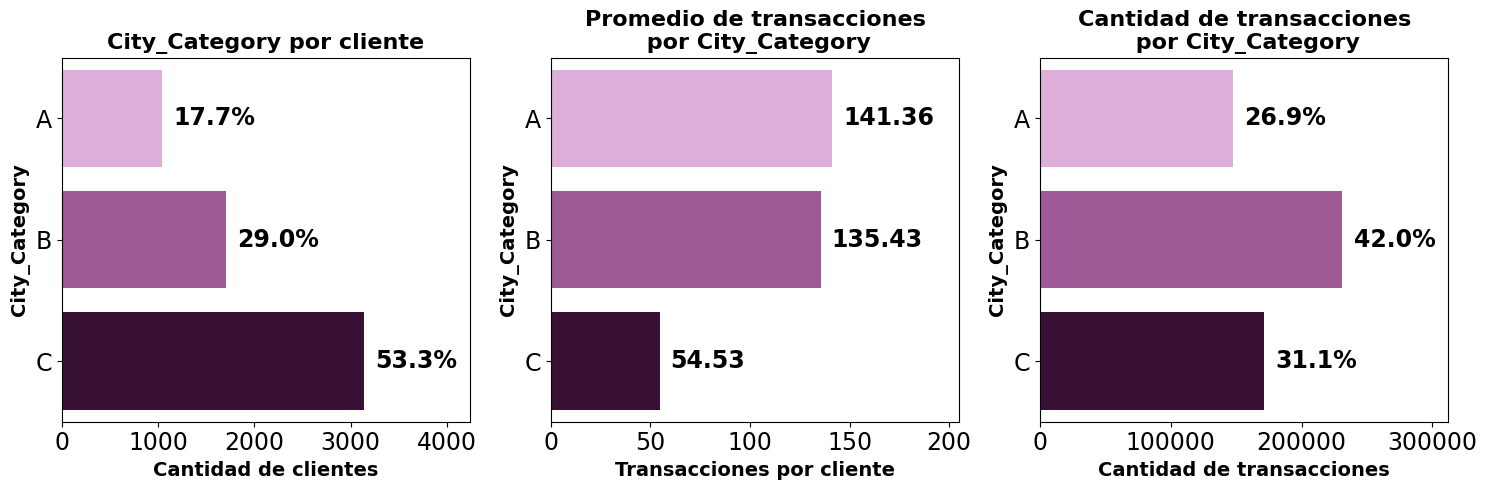

In [49]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_city = {
    'A': '#e6a6e0',
    'B': '#a84fa0',
    'C': '#3d0a38'
    }

# Panel 1: por cliente único
sns.countplot(y='City_Category', data=usuarios_unicos,
              order=['A', 'B', 'C'],
              ax=axes[0], hue='City_Category', palette=palette_city, legend=False)
axes[0].set_title('City_Category por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('City_Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[0].set_xlim(0, usuarios_unicos['City_Category'].value_counts().max() * 1.35)

# Panel 2: transacciones promedio por City_Category
tx_por_cliente = (
    data.groupby(['User_ID', 'City_Category']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('City_Category')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='City_Category', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['City_Category'],
    ax=axes[1], hue='City_Category', palette=palette_city, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por City_Category', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('City_Category', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.45)

# Panel 3: por transacción
sns.countplot(y='City_Category', data=data,
              order=['A', 'B', 'C'],
              ax=axes[2], hue='City_Category', palette=palette_city, legend=False)
axes[2].set_title('Cantidad de transacciones\n por City_Category', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('City_Category', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(data)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[2].set_xlim(0, data['City_Category'].value_counts().max() * 1.35)

plt.tight_layout()
plt.show()

En el análisis de City_Category vemos que la mayor cantidad de clientes está en la ciudad C (53.3%), seguida por B (29.0%) y A (17.7%). Sin embargo, algo muy interesante es que la ciudad A es la que en promedio realiza la mayor cantidad de transacciones por cliente (141.36), seguida de cerca por B (135.43), y bastante más atrás C (54.53) — las ciudades A y B realizan, respectivamente, ~159% y ~148% más transacciones por cliente que C. Esta combinación de factores opuestos — muchos clientes pero el promedio más bajo de las tres — explica que C no quede última en el total de transacciones (31.1%): su volumen de clientes compensa el bajo promedio individual. B lidera (42.0%) al combinar buena base de clientes con buen promedio, mientras que A, pese a tener el mejor promedio, queda última (26.9%) por ser la ciudad con menos clientes.

### Atributo `Marital_Status`

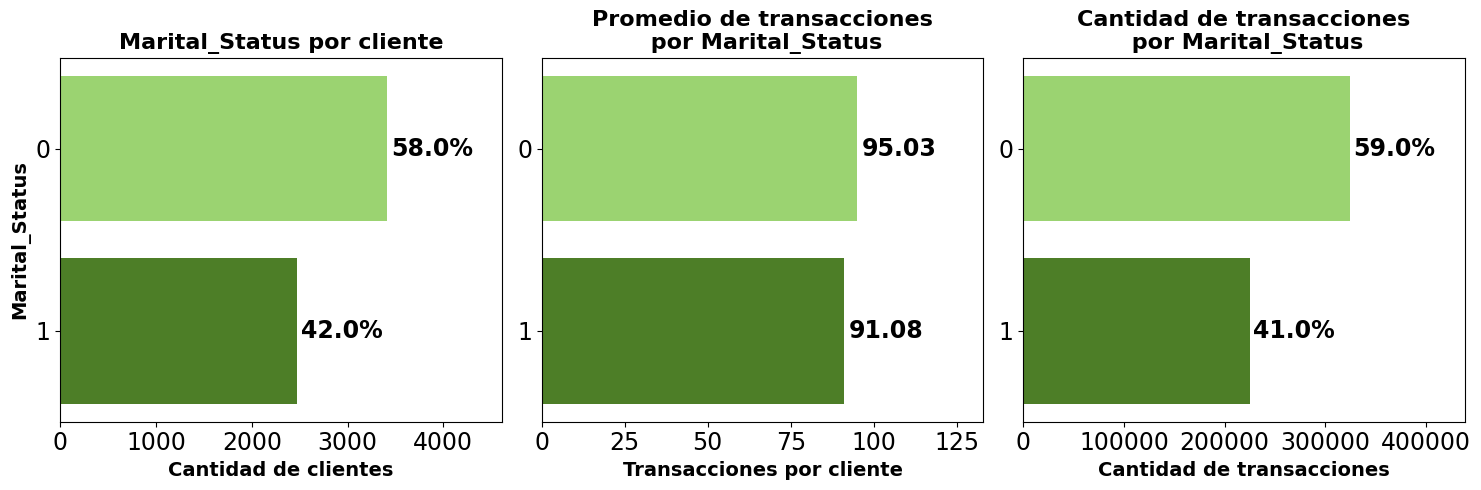

In [50]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_marital = {
    0: '#99e361',
    1: '#4b8d18'
    }

# Panel 1: por cliente único
sns.countplot(y='Marital_Status', data=usuarios_unicos,
              order=usuarios_unicos['Marital_Status'].value_counts().index,
              ax=axes[0], hue='Marital_Status', palette=palette_marital, legend=False)
axes[0].set_title('Marital_Status por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Marital_Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(3, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 2: transacciones promedio por Marital_Status
tx_por_cliente = (
    data.groupby(['User_ID', 'Marital_Status']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Marital_Status')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Marital_Status', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Marital_Status'],
    ax=axes[1], hue='Marital_Status', palette=palette_marital,
    orient='h',  # necesario: ambas columnas son numéricas, sin esto seaborn no dibuja las barras
    legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Marital_Status', fontsize=16, fontweight='bold')
# axes[1].set_ylabel('Marital_Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(3, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 3: por transacción
sns.countplot(y='Marital_Status', data=data,
              order=data['Marital_Status'].value_counts().index,
              ax=axes[2], hue='Marital_Status', palette=palette_marital, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Marital_Status', fontsize=16, fontweight='bold')
# axes[2].set_ylabel('Marital_Status', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(data)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(2, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )

# Panel 1
axes[0].set_xlim(0, usuarios_unicos['Marital_Status'].value_counts().max() * 1.35)
# Panel 2
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.40)
# Panel 3
axes[2].set_xlim(0, data['Marital_Status'].value_counts().max() * 1.35)

plt.tight_layout()
plt.show()

En el análisis de Marital_Status vemos que el grupo 0 es el más numeroso, representando el 58.0% de los clientes frente al 42.0% del grupo 1 — una diferencia de 16 puntos porcentuales. Sin embargo, el promedio de transacciones por cliente es muy similar entre ambos grupos (95.03 vs. 91.08), por lo que, a diferencia de lo observado en Gender y City_Category, la participación en el total de transacciones prácticamente no se corre respecto a la participación en clientes (58.0%→59.0% y 42.0%→41.0%). Esto sugiere que, en términos de frecuencia de compra, el estado civil no genera una diferencia relevante de comportamiento entre ambos grupos — algo que sí veíamos con las otras variables analizadas. Queda pendiente para más adelante evaluar si esta similitud se mantiene también en el monto gastado por transacción, o si ahí aparece una diferencia que acá no se observa.

### Atributo `Stay_In_Current_City_Years`

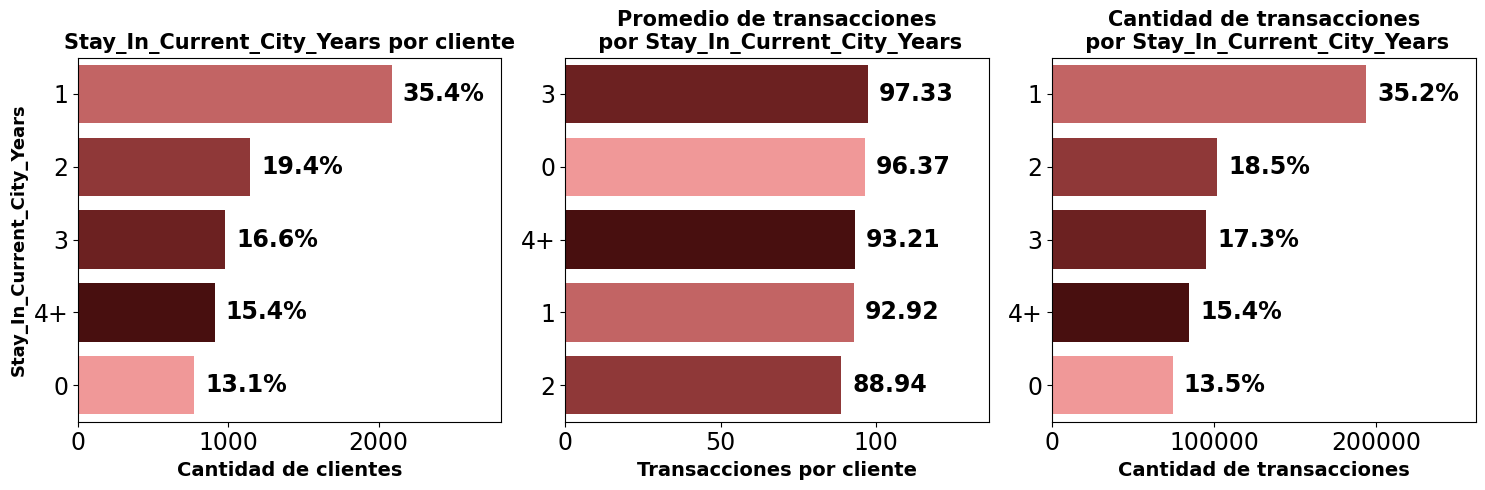

In [51]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette_cityyears = {
    '0': '#ff8989',
    '1': '#d15555',
    '2': '#9d2a2a',
    '3': '#781414',
    '4+': '#510606',
    }

# Panel 1: por cliente único
sns.countplot(y='Stay_In_Current_City_Years', data=usuarios_unicos,
              order=usuarios_unicos['Stay_In_Current_City_Years'].value_counts().index,
              ax=axes[0], hue='Stay_In_Current_City_Years', palette=palette_cityyears, legend=False)
axes[0].set_title('Stay_In_Current_City_Years por cliente', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Stay_In_Current_City_Years', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=17)

total_usuarios = len(usuarios_unicos)
for p in axes[0].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_usuarios) * 100:.1f}%'
    axes[0].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[0].set_xlim(0, usuarios_unicos['Stay_In_Current_City_Years'].value_counts().max() * 1.35)

# Panel 2: transacciones promedio por Stay_In_Current_City_Years
tx_por_cliente = (
    data.groupby(['User_ID', 'Stay_In_Current_City_Years']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Stay_In_Current_City_Years')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Stay_In_Current_City_Years', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Stay_In_Current_City_Years'],
    ax=axes[1], hue='Stay_In_Current_City_Years', palette=palette_cityyears, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Stay_In_Current_City_Years', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=17)

for p in axes[1].patches:
    ancho = p.get_width()
    axes[1].annotate(
        f'{ancho:.2f}', (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[1].set_xlim(0, promedio_tx['Transacciones'].max() * 1.40)

# Panel 3: por transacción
sns.countplot(y='Stay_In_Current_City_Years', data=data,
              order=data['Stay_In_Current_City_Years'].value_counts().index,
              ax=axes[2], hue='Stay_In_Current_City_Years', palette=palette_cityyears, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Stay_In_Current_City_Years', fontsize=15, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=17)

total_transacciones = len(data)
for p in axes[2].patches:
    ancho = p.get_width()
    porcentaje = f'{(ancho / total_transacciones) * 100:.1f}%'
    axes[2].annotate(
        porcentaje, (ancho, p.get_y() + p.get_height() / 2.0),
        ha='left', va='center', xytext=(8, 0), textcoords='offset points',
        fontsize=17, fontweight='bold',
    )
axes[2].set_xlim(0, data['Stay_In_Current_City_Years'].value_counts().max() * 1.35)

plt.tight_layout()
plt.show()

En el análisis de Stay_In_Current_City_Years vemos que la mayoría de los clientes lleva 1 año en su ciudad actual (35.4%), mientras que el grupo menos representado es el de 0 años (recién mudados, 13.1%). A diferencia de lo observado en Gender, Age y City_Category, acá los promedios de transacciones por cliente son muy parecidos entre todos los grupos (entre 88.94 y 97.33, una diferencia relativamente chica) — el grupo que más se despega, con el promedio más bajo, es el de 2 años (88.94). Como resultado de esta similitud entre promedios, el orden de representación se mantiene prácticamente idéntico entre la cantidad de clientes y la cantidad de transacciones (1 > 2 > 3 > 4+ > 0 en ambos casos, con porcentajes casi iguales) — el mismo patrón de estabilidad que ya habíamos visto en Marital_Status, donde promedios similares implican que el peso poblacional de cada grupo no se ve amplificado ni compensado por diferencias de comportamiento individual.

### Atributo `Occupation`

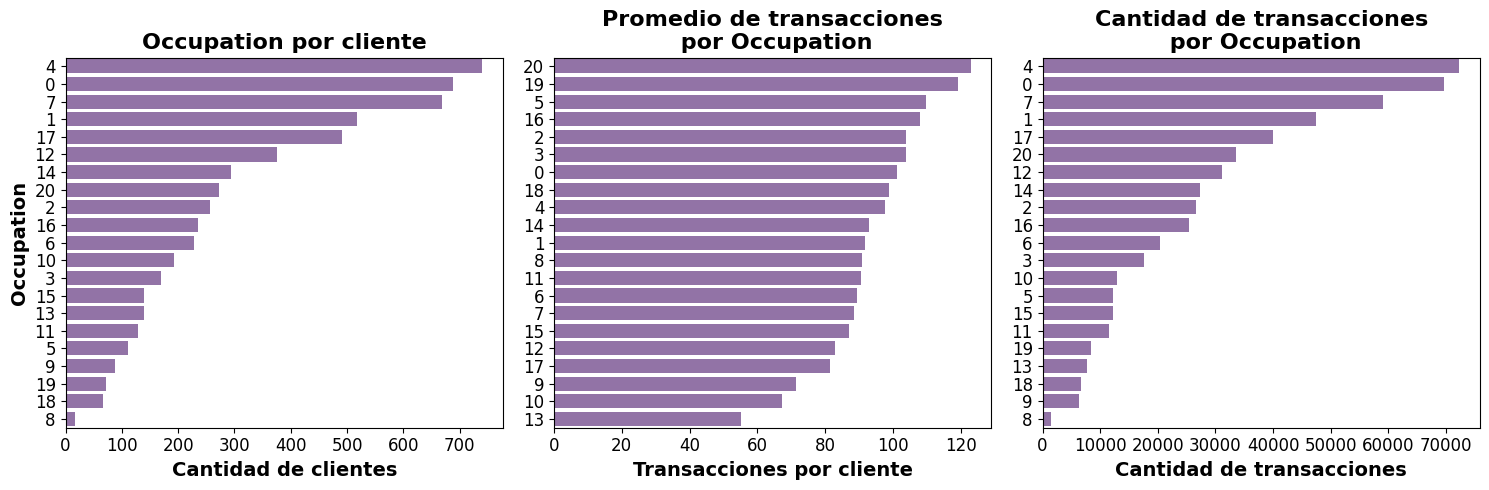

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

codigos_occupation = sorted(data['Occupation'].unique())
palette_occupation = {codigo: '#946BAE' for codigo in codigos_occupation}

# Panel 1: por cliente único
sns.countplot(y='Occupation', data=usuarios_unicos,
              order=usuarios_unicos['Occupation'].value_counts().index,
              ax=axes[0], hue='Occupation', palette=palette_occupation, legend=False)
axes[0].set_title('Occupation por cliente', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Occupation', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de clientes', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=12)

# Panel 2: transacciones promedio por Occupation
tx_por_cliente = (
    data.groupby(['User_ID', 'Occupation']).size().reset_index(name='Transacciones')
)
promedio_tx = (
    tx_por_cliente.groupby('Occupation')['Transacciones'].mean().reset_index()
)
sns.barplot(
    y='Occupation', x='Transacciones', data=promedio_tx,
    order=promedio_tx.sort_values(by='Transacciones', ascending=False)['Occupation'],
    ax=axes[1], hue='Occupation', palette=palette_occupation, orient='h', legend=False,
)
axes[1].set_title('Promedio de transacciones\n por Occupation', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Transacciones por cliente', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=12)

# Panel 3: por transacción
sns.countplot(y='Occupation', data=data,
              order=data['Occupation'].value_counts().index,
              ax=axes[2], hue='Occupation', palette=palette_occupation, legend=False)
axes[2].set_title('Cantidad de transacciones\n por Occupation', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Cantidad de transacciones', fontsize=14, fontweight='bold')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

El análisis de Occupation es más complejo por tratarse de 21 categorías sin significado conocido. Aun así, se observa que las cuatro ocupaciones más frecuentes en cantidad de clientes (4, 0, 7 y 1) se mantienen como las cuatro más frecuentes también en cantidad total de transacciones, y la ocupación menos representada (8) sigue siendo la última en ambos rankings — sugiriendo que, en los extremos, el comportamiento es consistente.

Sin embargo, en las posiciones intermedias sí aparecen corrimientos interesantes: la ocupación 20, que es solo la 8va en cantidad de clientes, tiene el promedio de transacciones por cliente más alto de las 21 categorías (~120), lo cual la impulsa hasta el 6to lugar en cantidad total de transacciones. En el sentido opuesto, la ocupación 13 tiene el promedio más bajo (~55) y, pese a partir de una posición intermedia en cantidad de clientes, cae varios puestos en el ranking de transacciones totales. Ambos casos son ejemplos del mismo mecanismo de amplificación/compensación que veníamos observando en otras variables: el promedio de transacciones por cliente puede correr a un grupo hacia arriba o hacia abajo en el ranking de volumen total, independientemente de cuántos clientes tenga.

In [53]:
# ¿Gender es siempre el mismo para un mismo User_ID? (debería serlo, es un dato demográfico fijo del cliente)
data.groupby('User_ID')['Gender'].nunique().value_counts()

Gender
1    5891
Name: count, dtype: int64

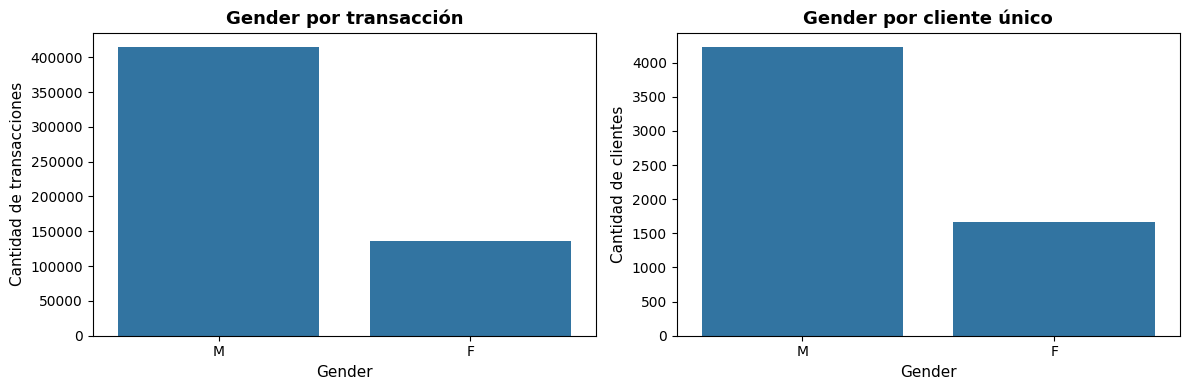

In [54]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: por transacción (lo que ya tenías)
sns.countplot(x='Gender', data=data,
              order=data['Gender'].value_counts().index, ax=axes[0])
axes[0].set_title('Gender por transacción', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Cantidad de transacciones', fontsize=11)

# Panel 2: por cliente único
sns.countplot(x='Gender', data=usuarios_unicos,
              order=usuarios_unicos['Gender'].value_counts().index, ax=axes[1])
axes[1].set_title('Gender por cliente único', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Cantidad de clientes', fontsize=11)

plt.tight_layout()
plt.show()

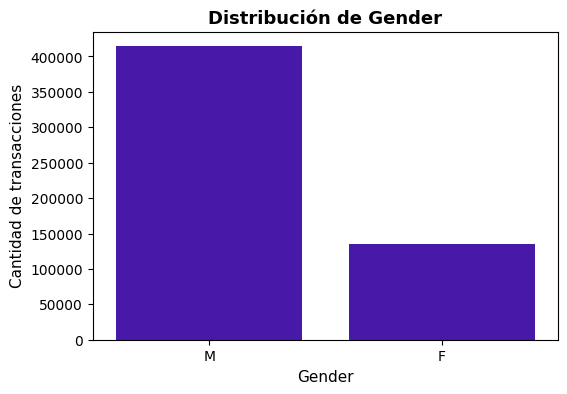

In [55]:
# Gender -> orden por frecuencia (no tiene orden inherente)
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=data,
              order=data['Gender'].value_counts().index, color="#4000C1")
plt.title('Distribución de Gender', fontsize=13, fontweight='bold')
plt.xlabel('Gender', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

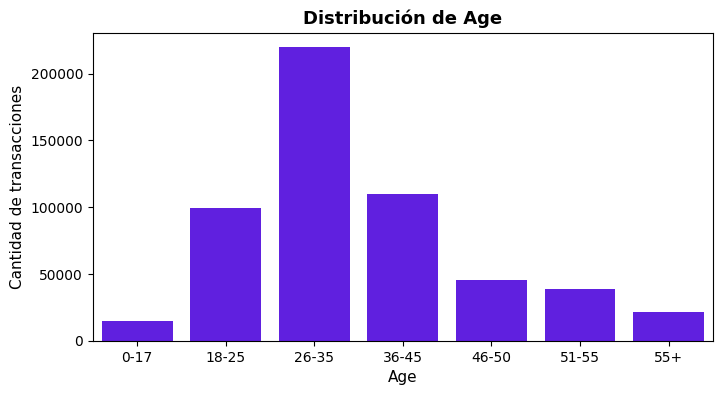

In [56]:
# Age -> orden natural (rangos etarios crecientes)
plt.figure(figsize=(8, 4))
sns.countplot(x='Age', data=data, order=sorted(data['Age'].unique()), color="#5500FF")
plt.title('Distribución de Age', fontsize=13, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

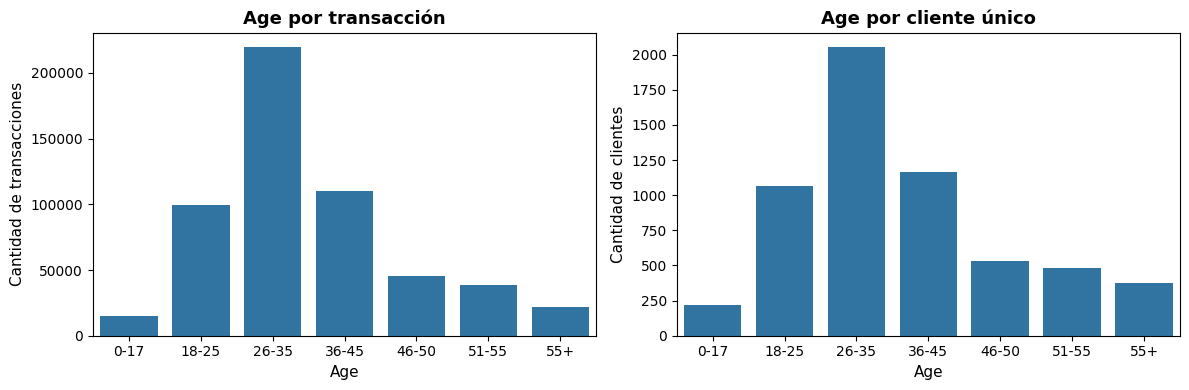

In [57]:
usuarios_unicos = data.drop_duplicates(subset='User_ID')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: por transacción (lo que ya tenías)
sns.countplot(x='Age', data=data,
              order=sorted(data['Age'].unique()), ax=axes[0])
axes[0].set_title('Age por transacción', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Cantidad de transacciones', fontsize=11)

# Panel 2: por cliente único
sns.countplot(x='Age', data=usuarios_unicos,
              order=sorted(usuarios_unicos['Age'].unique()), ax=axes[1])
axes[1].set_title('Age por cliente único', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Cantidad de clientes', fontsize=11)

plt.tight_layout()
plt.show()

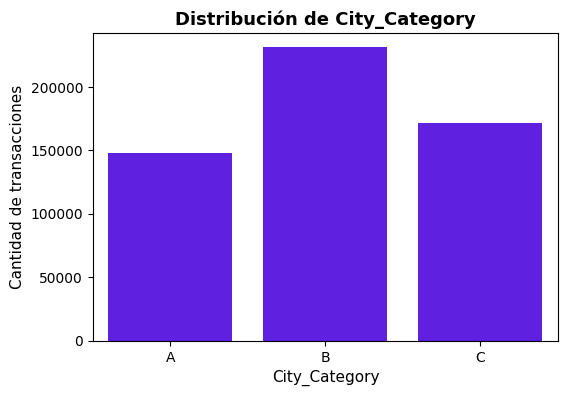

In [58]:
# City_Category -> mantenida alfabética A,B,C (nominal, pero de fácil lectura así)
plt.figure(figsize=(6, 4))
sns.countplot(x='City_Category', data=data, order=['A', 'B', 'C'], color="#5500FF")
plt.title('Distribución de City_Category', fontsize=13, fontweight='bold')
plt.xlabel('City_Category', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

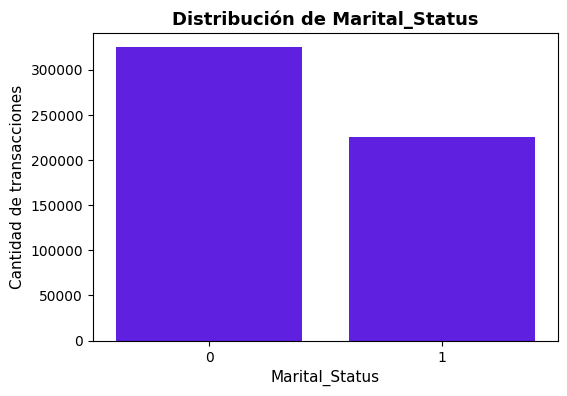

In [59]:
# Marital_Status -> orden por frecuencia (no tiene orden inherente, y no sabemos qué significa cada valor)
plt.figure(figsize=(6, 4))
sns.countplot(x='Marital_Status', data=data,
              order=data['Marital_Status'].value_counts().index, color="#5500FF")
plt.title('Distribución de Marital_Status', fontsize=13, fontweight='bold')
plt.xlabel('Marital_Status', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

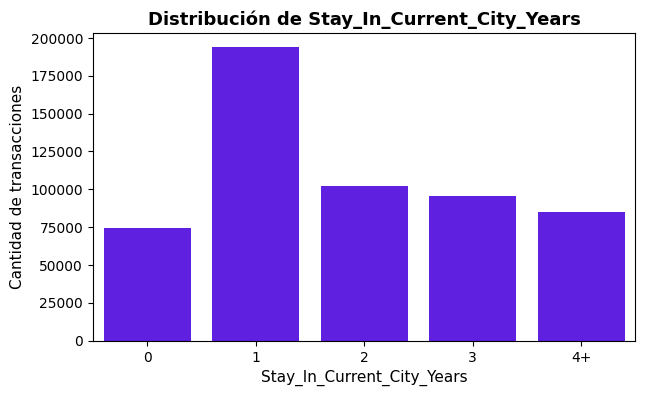

In [60]:
# Stay_In_Current_City_Years -> orden natural (años crecientes)
plt.figure(figsize=(7, 4))
sns.countplot(x='Stay_In_Current_City_Years', data=data,
              order=['0', '1', '2', '3', '4+'], color="#5500FF")
plt.title('Distribución de Stay_In_Current_City_Years', fontsize=13, fontweight='bold')
plt.xlabel('Stay_In_Current_City_Years', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

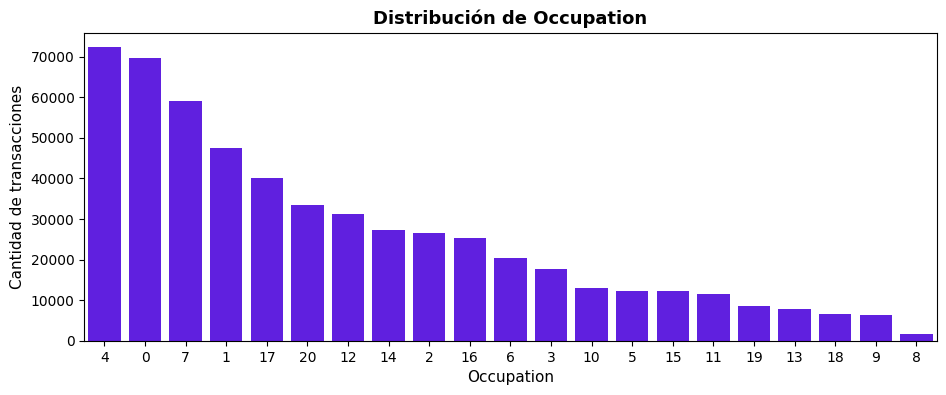

In [61]:
# Occupation -> orden por frecuencia (21 códigos sin significado conocido)
plt.figure(figsize=(11, 4))
sns.countplot(x='Occupation', data=data,
              order=data['Occupation'].value_counts().index, color="#5500FF")
plt.title('Distribución de Occupation', fontsize=13, fontweight='bold')
plt.xlabel('Occupation', fontsize=11)
plt.ylabel('Cantidad de transacciones', fontsize=11)
plt.show()

## c)

Con lo visto en el punto **2-a** podemos responder:
- ¿Está sesgada? Sí, la media ($9.264) es mayor que la mediana ($8.047), lo cual indica un sesgo positivo (hacia la derecha): una cola de compras de mayor monto "estira" el promedio por encima del valor típico de la distribución.

- ¿Existen valores extremos? El boxplot marca varios puntos como outliers estadísticos en la cola superior. Sin embargo, no se trata de errores de carga: son transacciones reales de montos altos, por lo que no corresponde eliminarlos del análisis.

- ¿Cómo es el comportamiento general del gasto? La distribución es multimodal, con varios picos bien diferenciados en lugar de una única campana, probablemente porque distintas categorías de producto tienen rangos de precio característicos (hipótesis a confirmar coloreando el histograma por Product_Category_1, análisis que queda para más adelante). El grueso de las compras se concentra entre los cuantiles 25% ($5.823) y 75% ($12.054), con la mitad central de las transacciones en ese rango.


## d)

### 1) ¿Cuál es la distribución de los clientes por género?

En el punto 2b) se respondió esta pregunta: 71.7% hombres y 28.3% mujeres. Sin embargo, quedó pendiente relacionar Gender con Purchase, análisis que se realiza a continuación.

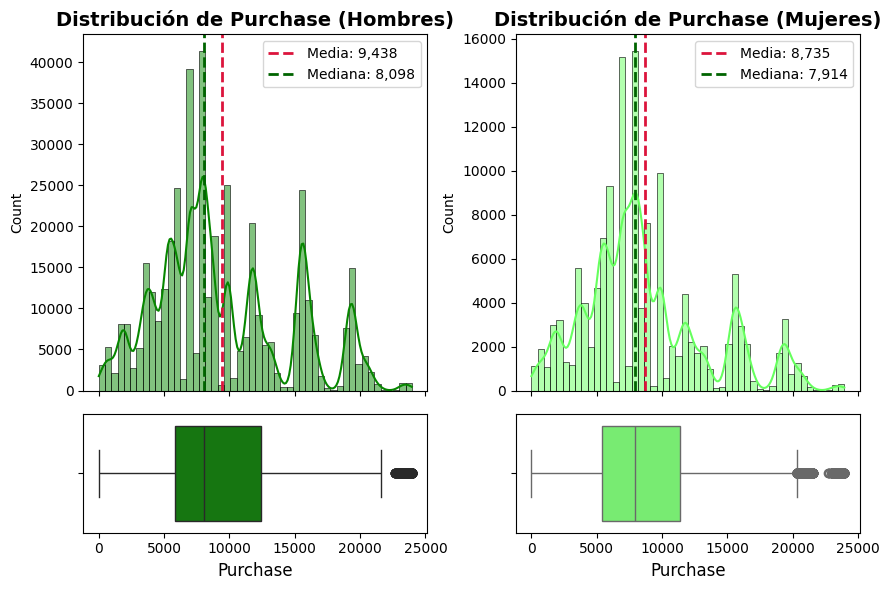

In [68]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 6),
    sharex=True,                       
    gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(data[data['Gender']=='M']['Purchase'], bins=50, kde=True, color="#078700", ax=axes[0,0])
axes[0,0].set_title("Distribución de Purchase (Hombres)", fontsize=14, fontweight="bold")
axes[0,0].set_xlabel("")

media = data[data['Gender']=='M']['Purchase'].mean()
mediana = data[data['Gender']=='M']['Purchase'].median()

axes[0,0].axvline(media, color="crimson", linestyle="--", linewidth=2,
                 label=f"Media: {media:,.0f}")
axes[0,0].axvline(mediana, color="darkgreen", linestyle="--", linewidth=2,
                 label=f"Mediana: {mediana:,.0f}")

axes[0,0].legend(fontsize=10)

sns.boxplot(x=data[data['Gender']=='M']['Purchase'], color="#078700", ax=axes[1,0])
axes[1,0].set_xlabel("Purchase", fontsize=12)

sns.histplot(data[data['Gender']=='F']['Purchase'], bins=50, kde=True, color="#66FF5E", ax=axes[0,1])
axes[0,1].set_title("Distribución de Purchase (Mujeres)", fontsize=14, fontweight="bold")
axes[0,1].set_xlabel("")

media = data[data['Gender']=='F']['Purchase'].mean()
mediana = data[data['Gender']=='F']['Purchase'].median()

axes[0,1].axvline(media, color="crimson", linestyle="--", linewidth=2,
                 label=f"Media: {media:,.0f}")
axes[0,1].axvline(mediana, color="darkgreen", linestyle="--", linewidth=2,
                 label=f"Mediana: {mediana:,.0f}")

axes[0,1].legend(fontsize=10)

sns.boxplot(x=data[data['Gender']=='F']['Purchase'], color="#66FF5E", ax=axes[1,1])
axes[1,1].set_xlabel("Purchase", fontsize=12)

plt.tight_layout()
plt.show()

In [69]:
p90 = data['Purchase'].quantile(0.90)

resultados = []
for genero in ['M', 'F']:
    sub = data[data['Gender'] == genero]
    pct = (sub['Purchase'] > p90).mean() * 100
    resultados.append({'Gender': genero, 'Pct_sobre_P90': pct})

pd.DataFrame(resultados)

,Gender,Pct_sobre_P90
0,M,10.612202
1,F,8.128327


Comparando la distribución de Purchase entre géneros, la mediana es muy similar entre ambos ($8.098 en hombres, $7.914 en mujeres), lo cual indica que el grueso de las compras tiene un monto parecido independientemente del género. Sin embargo, la media es notablemente mayor en hombres ($9.438 vs. $8.735), lo cual sugiere que los hombres tienen una cola de compras de montos altos algo más pesada que las mujeres, visible también en el boxplot, donde el grupo de outliers en la cola superior es más denso y se extiende más lejos para los hombres. Usando como umbral el percentil 90 general de Purchase ($16.317), el 10.61% de las transacciones de los hombres supera ese monto, frente al 8.13% de las mujeres, una diferencia de ~2.5 puntos porcentuales que confirma numéricamente esa mayor presencia de compras caras entre los hombres.

c:\Users\pigna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\pigna\AppData\Local\Temp\ipykernel_8852\1712016571.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


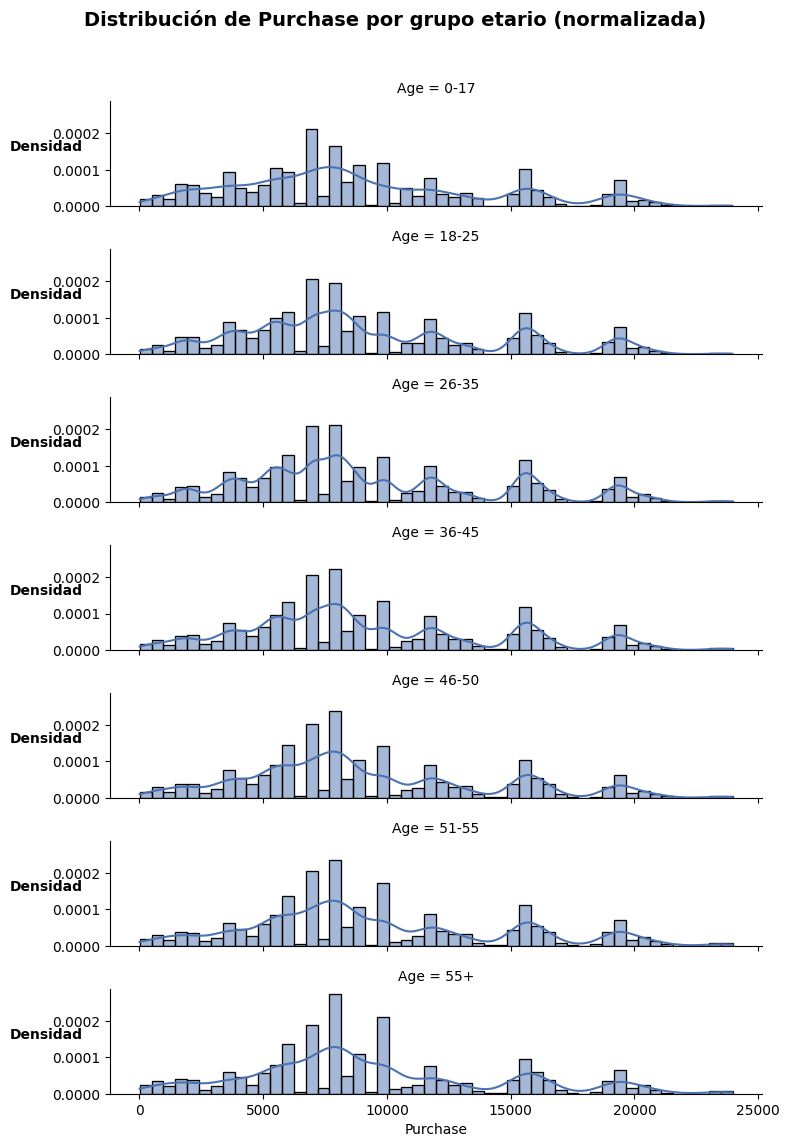

In [24]:
edades_ordenadas = sorted(data['Age'].unique())

g = sns.FacetGrid(data, row='Age', row_order=edades_ordenadas,
                   height=1.6, aspect=5, sharex=True, sharey=True)
g.map(sns.histplot, 'Purchase', bins=50, kde=True, stat='density', color="#4C72B0")

for ax, edad in zip(g.axes.flat, edades_ordenadas):
    ax.set_ylabel(edad, rotation=0, ha='right', fontsize=10, fontweight='bold')

g.set_axis_labels("Purchase", "Densidad")
g.fig.suptitle("Distribución de Purchase por grupo etario (normalizada)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
gasto_por_usuario = data.groupby('User_ID').agg(
    Purchase_total=('Purchase', 'sum'),
    Age=('Age', 'first')  # Age es fijo por usuario, tomamos cualquiera
).reset_index()

c:\Users\pigna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\pigna\AppData\Local\Temp\ipykernel_8852\1552862299.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


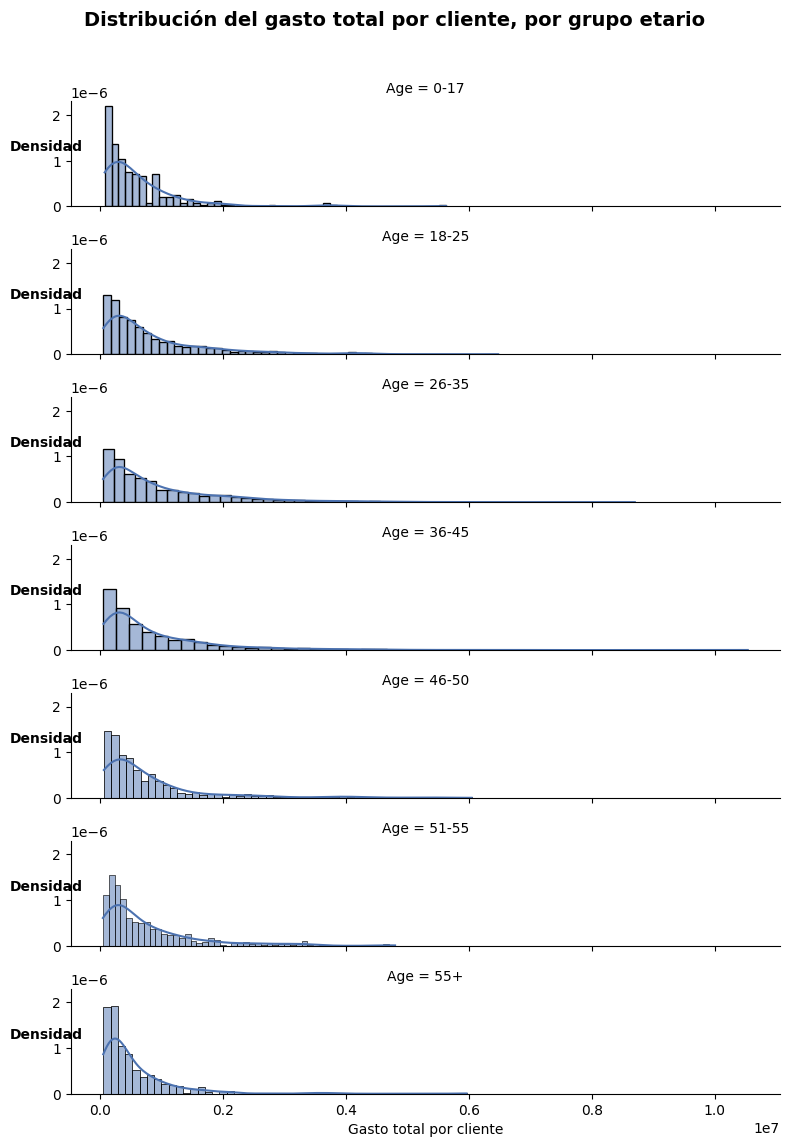

In [26]:
edades_ordenadas = sorted(gasto_por_usuario['Age'].unique())

g = sns.FacetGrid(gasto_por_usuario, row='Age', row_order=edades_ordenadas,
                   height=1.6, aspect=5, sharex=True, sharey=True)
g.map(sns.histplot, 'Purchase_total', bins=50, kde=True, stat='density', color="#4C72B0")

for ax, edad in zip(g.axes.flat, edades_ordenadas):
    ax.set_ylabel(edad, rotation=0, ha='right', fontsize=10, fontweight='bold')

g.set_axis_labels("Gasto total por cliente", "Densidad")
g.fig.suptitle("Distribución del gasto total por cliente, por grupo etario", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

c:\Users\pigna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
c:\Users\pigna\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\pigna\AppData\Local\Temp\ipykernel_8852\818976945.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


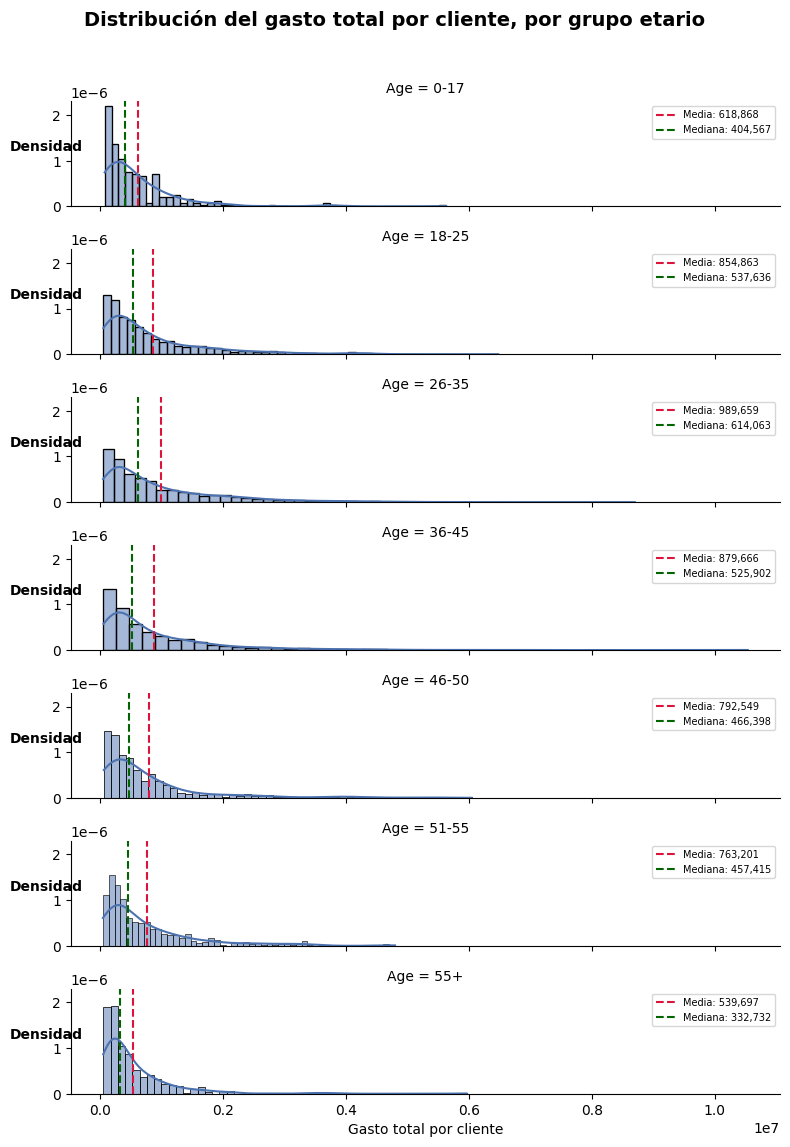

In [27]:
def marcar_media_mediana(x, **kwargs):
    ax = plt.gca()
    media = x.mean()
    mediana = x.median()
    ax.axvline(media, color="crimson", linestyle="--", linewidth=1.5,
               label=f"Media: {media:,.0f}")
    ax.axvline(mediana, color="darkgreen", linestyle="--", linewidth=1.5,
               label=f"Mediana: {mediana:,.0f}")

edades_ordenadas = sorted(gasto_por_usuario['Age'].unique())

g = sns.FacetGrid(gasto_por_usuario, row='Age', row_order=edades_ordenadas,
                   height=1.6, aspect=5, sharex=True, sharey=True)
g.map(sns.histplot, 'Purchase_total', bins=50, kde=True, stat='density', color="#4C72B0")
g.map(marcar_media_mediana, 'Purchase_total')

for ax, edad in zip(g.axes.flat, edades_ordenadas):
    ax.set_ylabel(edad, rotation=0, ha='right', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')

g.set_axis_labels("Gasto total por cliente", "Densidad")
g.fig.suptitle("Distribución del gasto total por cliente, por grupo etario", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## d

## e

## f

## g